<a href="https://colab.research.google.com/github/razokiyassine/Network-Intrusion-Detection/blob/main/Network_Intrusion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
# ==========================================
# 1. IMPORTATION DES BIBLIOTHÈQUES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 2. CHARGEMENT ET VÉRIFICATION DU FICHIER
# ==========================================
# Chargement direct du fichier téléversé
df = pd.read_csv("Test_data.csv")
print("Dimensions brutes :", df.shape)

Dimensions brutes : (22544, 41)


In [58]:
# ==========================================
# 3. NETTOYAGE DES DONNÉES (DATA CLEANING)
# ==========================================
# Détection et suppression des doublons
doublons = df.duplicated().sum()
print(f"Nombre de doublons détectés : {doublons}")
df_cleaned = df.drop_duplicates()

Nombre de doublons détectés : 57


In [59]:
# Vérification des valeurs manquantes sur les variables clés
valeurs_nulles = df_cleaned[['count', 'srv_count']].isnull().sum().sum()
print(f"Valeurs manquantes sur (count, srv_count) : {valeurs_nulles}")

Valeurs manquantes sur (count, srv_count) : 0


In [60]:
# Définition des variables :
# X : nombre de connexions vers le même hôte sur 2s (count)
# y : nombre de connexions vers le même service sur 2s (srv_count)
X = df_cleaned[['count']]
y = df_cleaned['srv_count']
print("Données après nettoyage :", df_cleaned.shape)

Données après nettoyage : (22487, 41)


In [61]:
# ==========================================
# 4. SÉPARATION TRAIN / TEST ET MODÉLISATION
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Entraînement de la régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

beta0 = model.intercept_
beta1 = model.coef_[0]

print("\n--- PARAMÈTRES DU MODÈLE ---")
print(f"β0 (Intercept) : {beta0:.4f}")
print(f"β1 (Pente)     : {beta1:.4f}")
print(f"Équation de régression : ŷ = {beta0:.2f} + {beta1:.2f} * count")


--- PARAMÈTRES DU MODÈLE ---
β0 (Intercept) : -0.0834
β1 (Pente)     : 0.3882
Équation de régression : ŷ = -0.08 + 0.39 * count


In [62]:
# ==========================================
# 5. ÉVALUATION DU MODÈLE
# ==========================================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- MÉTRIQUES D'ÉVALUATION ---")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


--- MÉTRIQUES D'ÉVALUATION ---
MAE  : 37.36
MSE  : 5642.29
RMSE : 75.12
R²   : 0.3757


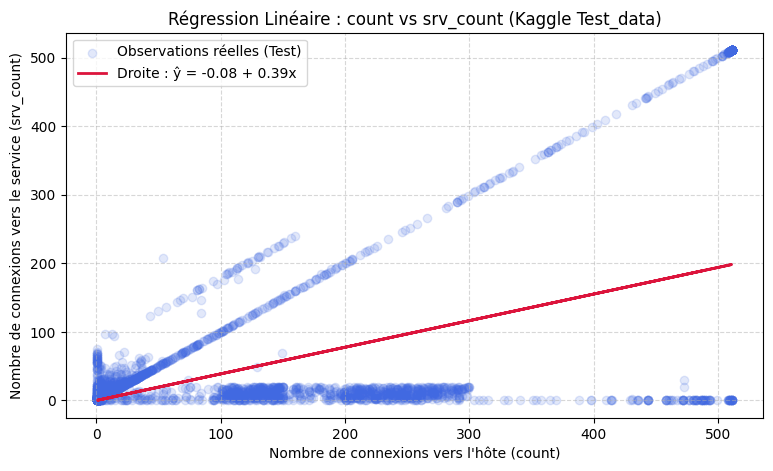

In [63]:
# ==========================================
# 6. VISUALISATIONS (VISUALIZAT°)
# ==========================================
# Tracé 1 : Droite de régression linéaire
plt.figure(figsize=(9, 5))
plt.scatter(X_test, y_test, alpha=0.15, color="royalblue", label="Observations réelles (Test)")
plt.plot(X_test, y_pred, color="crimson", linewidth=2, label=f"Droite : ŷ = {beta0:.2f} + {beta1:.2f}x")
plt.xlabel("Nombre de connexions vers l'hôte (count)")
plt.ylabel("Nombre de connexions vers le service (srv_count)")
plt.title("Régression Linéaire : count vs srv_count (Kaggle Test_data)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

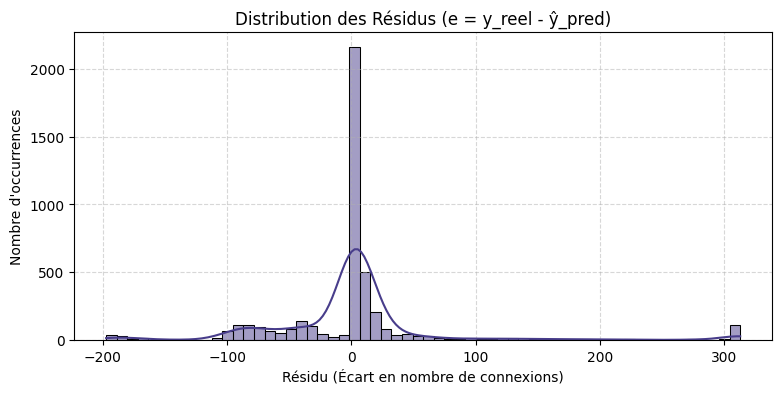

In [64]:
# Tracé 2 : Distribution des résidus
residus = y_test - y_pred
plt.figure(figsize=(9, 4))
sns.histplot(residus, bins=60, kde=True, color="darkslateblue")
plt.title("Distribution des Résidus (e = y_reel - ŷ_pred)")
plt.xlabel("Résidu (Écart en nombre de connexions)")
plt.ylabel("Nombre d'occurrences")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [65]:
# ==========================================
# 7. DÉTECTION ET ANALYSE DES ANOMALIES
# ==========================================
resultats_test = X_test.copy()
resultats_test['service'] = df_cleaned.loc[X_test.index, 'service']
resultats_test['flag'] = df_cleaned.loc[X_test.index, 'flag']
resultats_test['srv_count_reel'] = y_test
resultats_test['srv_count_pred'] = y_pred
resultats_test['residu'] = residus
resultats_test['residu_abs'] = residus.abs()

In [66]:
# Seuil d'investigation statistique fixé à 3 écarts-types (règle des 3-sigmas)
seuil = 3 * residus.std()
print(f"\nSeuil d'alerte statistique (3 * σ) : {seuil:.2f}")

resultats_test['anomalie_detectee'] = resultats_test['residu_abs'] > seuil

print("\n--- TOP 5 ANOMALIES POSITIVES (y >> ŷ) ---")
display(resultats_test.sort_values(by="residu", ascending=False).head(5))

print("\n--- TOP 5 ANOMALIES NÉGATIVES (y << ŷ) ---")
display(resultats_test.sort_values(by="residu", ascending=True).head(5))


Seuil d'alerte statistique (3 * σ) : 225.22

--- TOP 5 ANOMALIES POSITIVES (y >> ŷ) ---


,count,service,flag,srv_count_reel,srv_count_pred,residu,residu_abs,anomalie_detectee
12687,511,private,SF,511,198.275312,312.724688,312.724688,True
11824,511,private,SF,511,198.275312,312.724688,312.724688,True
3827,511,private,SF,511,198.275312,312.724688,312.724688,True
6663,511,private,SF,511,198.275312,312.724688,312.724688,True
10340,511,private,SF,511,198.275312,312.724688,312.724688,True



--- TOP 5 ANOMALIES NÉGATIVES (y << ŷ) ---


,count,service,flag,srv_count_reel,srv_count_pred,residu,residu_abs,anomalie_detectee
790,511,other,REJ,1,198.275312,-197.275312,197.275312,False
13917,511,other,REJ,1,198.275312,-197.275312,197.275312,False
19383,511,other,REJ,1,198.275312,-197.275312,197.275312,False
15720,511,other,REJ,1,198.275312,-197.275312,197.275312,False
13139,511,other,REJ,1,198.275312,-197.275312,197.275312,False
